In [1]:
# 1) Importar librerías
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from scipy import stats
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler # Estandarización de variables numéricas
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.metrics import roc_curve, roc_auc_score
from sklearn.inspection import permutation_importance

In [2]:
df = pd.read_csv('companyattrition.csv')
df

,satisfaction_level,last_evaluation,average_montly_hours,time_spend_company,work_accident,promotion_last_5years,dept,salary,resigned
0,0.58,0.74,215,3,0,0,sales,low,YES
1,0.82,0.67,202,3,0,0,sales,low,YES
2,0.45,0.69,193,3,0,0,sales,low,YES
3,0.78,0.82,247,3,0,0,sales,low,YES
4,0.49,0.60,214,2,0,0,sales,low,YES
...,...,...,...,...,...,...,...,...,...
14994,0.40,0.57,151,3,0,0,support,low,NO
14995,0.37,0.48,160,3,0,0,support,low,NO
14996,0.37,0.53,143,3,0,0,support,low,NO
14997,0.11,0.96,280,4,0,0,support,low,NO


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14999 entries, 0 to 14998
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   satisfaction_level     14999 non-null  float64
 1   last_evaluation        14999 non-null  float64
 2   average_montly_hours   14999 non-null  int64  
 3   time_spend_company     14999 non-null  int64  
 4   work_accident          14999 non-null  int64  
 5   promotion_last_5years  14999 non-null  int64  
 6   dept                   14999 non-null  object 
 7   salary                 14999 non-null  object 
 8   resigned               14999 non-null  object 
dtypes: float64(2), int64(4), object(3)
memory usage: 1.0+ MB


#  Relación entre las variables ‘satisfaction_level’  Y‘last_evaluation’

La correlación entre 'satisfaction_level' y 'last_evaluation' es: 0.10502121397148495


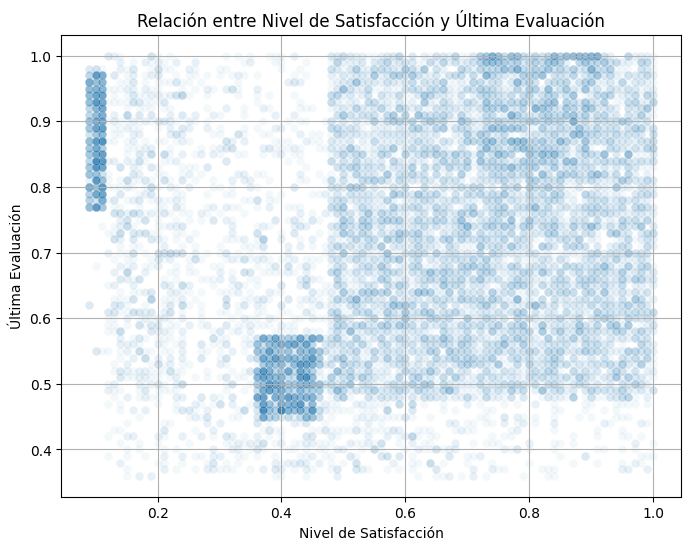

In [4]:
correlation = df['satisfaction_level'].corr(df['last_evaluation'])
print(f"La correlación entre 'satisfaction_level' y 'last_evaluation' es: {correlation}")

plt.figure(figsize=(8, 6))
sns.scatterplot(x='satisfaction_level', y='last_evaluation', data=df, alpha=0.05)
plt.title('Relación entre Nivel de Satisfacción y Última Evaluación')
plt.xlabel('Nivel de Satisfacción')
plt.ylabel('Última Evaluación')
plt.grid(True)
plt.show()

# Verificar si hay datos faltantes

In [5]:
# Verificar si hay datos faltantes
print("Datos faltantes por columna:")
print(df.isnull().sum())

# En este caso, no hay datos faltantes, por lo que no se requiere imputación.

scaler = StandardScaler()
df[['satisfaction_level', 'last_evaluation']] = scaler.fit_transform(df[['satisfaction_level', 'last_evaluation']])

# Codificación de variables categóricas
# Codificación ordinal para 'salary'
salary_map = {'low': 0, 'medium': 1, 'high': 2}
df.salary = df.salary.map(salary_map)

# Codificación binaria para 'resigned'
resigned_map = {'YES': 1, 'NO': 0}
df.resigned = df.resigned.map(resigned_map)

print("\nDataFrame después de la estandarización y codificación:")
df

Datos faltantes por columna:
satisfaction_level       0
last_evaluation          0
average_montly_hours     0
time_spend_company       0
work_accident            0
promotion_last_5years    0
dept                     0
salary                   0
resigned                 0
dtype: int64

DataFrame después de la estandarización y codificación:


,satisfaction_level,last_evaluation,average_montly_hours,time_spend_company,work_accident,promotion_last_5years,dept,salary,resigned
0,-0.132062,0.139622,215,3,0,0,sales,0,1
1,0.833258,-0.269343,202,3,0,0,sales,0,1
2,-0.654943,-0.152496,193,3,0,0,sales,0,1
3,0.672371,0.607012,247,3,0,0,sales,0,1
4,-0.494057,-0.678309,214,2,0,0,sales,0,1
...,...,...,...,...,...,...,...,...,...
14994,-0.856051,-0.853580,151,3,0,0,support,0,0
14995,-0.976716,-1.379394,160,3,0,0,support,0,0
14996,-0.976716,-1.087275,143,3,0,0,support,0,0
14997,-2.022479,1.424944,280,4,0,0,support,0,0


#  Verifica si es posible prescindir de alguna variable, además de justificar la precisión de tu modelo

In [6]:
#  Verifica si es posible prescindir de alguna variable, además de justificar la precisión de tu modelo

logit_model = smf.logit('resigned ~ satisfaction_level + last_evaluation + average_montly_hours + time_spend_company + work_accident + promotion_last_5years + salary', data=df)
result = logit_model.fit()
print(result.summary())

Optimization terminated successfully.
         Current function value: 0.439346
         Iterations 7
                           Logit Regression Results                           
Dep. Variable:               resigned   No. Observations:                14999
Model:                          Logit   Df Residuals:                    14991
Method:                           MLE   Df Model:                            7
Date:                Sun, 21 Sep 2025   Pseudo R-squ.:                  0.1995
Time:                        20:59:51   Log-Likelihood:                -6589.7
converged:                       True   LL-Null:                       -8232.3
Covariance Type:            nonrobust   LLR p-value:                     0.000
                            coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------
Intercept                 1.9083      0.106     18.052      0.000       1.701       2.

La variable ***last_evaluation*** tiene un p-valor de 0.788, lo que indica que no es estadísticamente significativa en este modelo.


In [19]:
#Quitar last_evaluation del modelo
df_cleaned = df.dropna()
logit_model = smf.logit('resigned ~ satisfaction_level + average_montly_hours + time_spend_company + work_accident + promotion_last_5years + salary', data=df_cleaned)
result = logit_model.fit()
print(result.summary())

Optimization terminated successfully.
         Current function value: 0.439348
         Iterations 7
                           Logit Regression Results                           
Dep. Variable:               resigned   No. Observations:                14999
Model:                          Logit   Df Residuals:                    14992
Method:                           MLE   Df Model:                            6
Date:                Sun, 21 Sep 2025   Pseudo R-squ.:                  0.1995
Time:                        22:04:32   Log-Likelihood:                -6589.8
converged:                       True   LL-Null:                       -8232.3
Covariance Type:            nonrobust   LLR p-value:                     0.000
                            coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------
Intercept                 1.9204      0.096     20.093      0.000       1.733       2.

# Modelo de regresión logística

In [18]:
# Prepare data for logistic regression
# Variables independientes (predictoras)
X = df[['satisfaction_level',
 'average_montly_hours',
 'time_spend_company',
 'work_accident',
 'promotion_last_5years',
 'salary']]

# Variable dependiente (objetivo)
y = df['resigned']

In [9]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [10]:
model = LogisticRegression()
model.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

In [11]:
#Orden de importancia de las variables
# A mayor valor, más importancia

result=permutation_importance(model, X_train, y_train, n_repeats=10, random_state=42, n_jobs=-1)
print(result.importances_mean)

[ 0.04848737 -0.00364197 -0.02125177  0.01080923  0.00094175  0.00740062]


In [12]:
X_test.columns.to_list()

['satisfaction_level',
 'average_montly_hours',
 'time_spend_company',
 'work_accident',
 'promotion_last_5years',
 'salary']

In [13]:
sorted(zip(result.importances_mean, X_test.columns.to_list()))

[(np.float64(-0.02125177098091511), 'time_spend_company'),
 (np.float64(-0.003641970164180408), 'average_montly_hours'),
 (np.float64(0.0009417451454287517), 'promotion_last_5years'),
 (np.float64(0.007400616718059816), 'salary'),
 (np.float64(0.010809234102841892), 'work_accident'),
 (np.float64(0.04848737394782896), 'satisfaction_level')]

In [14]:
print("Coeficientes del modelo:", model.coef_)
print("Intercepto del modelo:", model.intercept_)

Coeficientes del modelo: [[ 0.9297781  -0.00154138 -0.21600004  1.53062889  1.2015039   0.68100172]]
Intercepto del modelo: [1.91852323]


In [15]:
y_pred = model.predict(X_test)

print("Precisión del modelo:", accuracy_score(y_test, y_pred))

print("\nMatriz de confusión:")
print(confusion_matrix(y_test, y_pred))

print("\nReporte de clasificación:")
print(classification_report(y_test, y_pred))


Precisión del modelo: 0.7726666666666666

Matriz de confusión:
[[ 157  531]
 [ 151 2161]]

Reporte de clasificación:
              precision    recall  f1-score   support

           0       0.51      0.23      0.32       688
           1       0.80      0.93      0.86      2312

    accuracy                           0.77      3000
   macro avg       0.66      0.58      0.59      3000
weighted avg       0.74      0.77      0.74      3000



- Precisión (precision): qué proporción de predicciones positivas fueron correctas.
- Recall: qué proporción de casos reales fueron detectados.
- F1-score: balance entre precisión y recall.

Interpretación:
- El modelo es muy bueno para detectar renuncias (clase 1).
- Pero es débil para detectar permanencias (clase 0): bajo recall (0.23) y F1-score (0.32).
- Esto puede deberse a un desbalance de clases: hay muchos más renunciantes que no-renunciantes en el dataset.


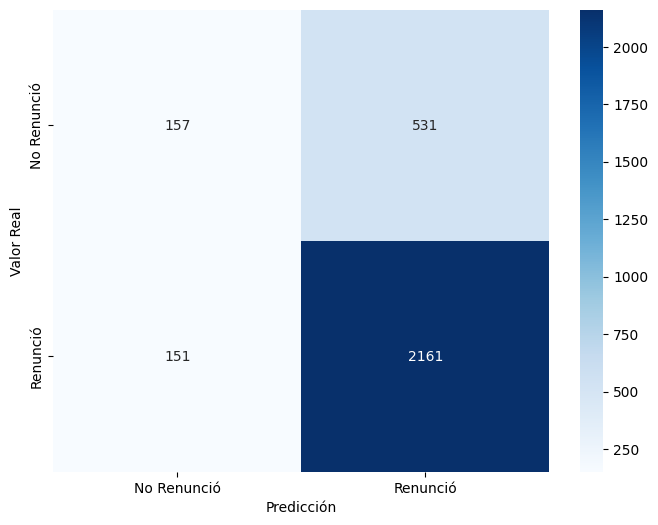

In [16]:
#Construye el gráfico de matriz de confusión
conf_matrix = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',xticklabels=['No Renunció', 'Renunció'], yticklabels=['No Renunció', 'Renunció'])
plt.xlabel('Predicción')
plt.ylabel('Valor Real')
plt.show()

- Clase 0 (no renunció): solo 157 fueron correctamente clasificados, mientras que 531 fueron mal clasificados como renunciantes.
- Clase 1 (renunció): el modelo acertó en 2161 casos y falló en 151.
- Esto indica que el modelo detecta bien a quienes renuncian, pero falla mucho en identificar a quienes permanecen


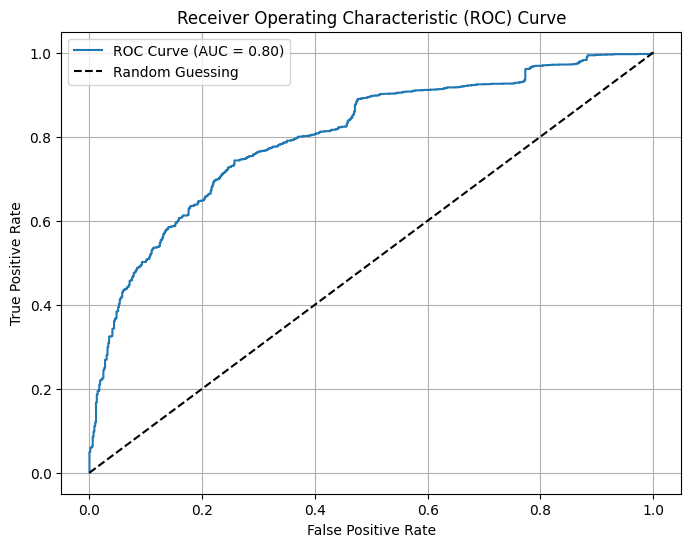

Area Under the ROC Curve (AUC): 0.80


In [17]:
#GRAFICA LA CURVA ROC
y_pred_prob = model.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)
auc = roc_auc_score(y_test, y_pred_prob)

# Plot ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {auc:.2f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random Guessing') # Random guessing line
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend()
plt.grid(True)
plt.show()

print(f"Area Under the ROC Curve (AUC): {auc:.2f}")